**ML COURSE 2025-2026**
# LAB9  EXPLAINABLE AI

In this notebook, we will see some techniques to explain machine learning model predictions.

In [1]:
import random
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings("ignore")

random.seed(0)
np.random.seed(0)

## Dataset: loading and pre-processing

The dataset is a collection of records on a heart condition called AHD. Our task is to predict if a patient has it based solely on age, gender, chest pain, cholesterol, and other heart and lung function measurements for a total of 13 features.

In [2]:
# download the dataset
csv_dataset = pd.read_csv("https://www.statlearning.com/s/Heart.csv")
csv_dataset = csv_dataset.drop(csv_dataset.columns[0], axis=1)
display(csv_dataset)

,Age,Sex,ChestPain,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,Thal,AHD
0,63,1,typical,145,233,1,2,150,0,2.3,3,0.0,fixed,No
1,67,1,asymptomatic,160,286,0,2,108,1,1.5,2,3.0,normal,Yes
2,67,1,asymptomatic,120,229,0,2,129,1,2.6,2,2.0,reversable,Yes
3,37,1,nonanginal,130,250,0,0,187,0,3.5,3,0.0,normal,No
4,41,0,nontypical,130,204,0,2,172,0,1.4,1,0.0,normal,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,45,1,typical,110,264,0,0,132,0,1.2,2,0.0,reversable,Yes
299,68,1,asymptomatic,144,193,1,0,141,0,3.4,2,2.0,reversable,Yes
300,57,1,asymptomatic,130,131,0,0,115,1,1.2,2,1.0,reversable,Yes
301,57,0,nontypical,130,236,0,2,174,0,0.0,2,1.0,normal,Yes


**GENERAL COMMMENT**

**Encoding of categorical features.**

<u>One hot encoding</u> converts a categorical feature into binary <u>vector</u>. Each category is represented by a vector with a 1 in the position of the category and 0s elsewhere. 

Example for ChestPain:
Categories = `[typical, asymptomatic, nonanginal, nontypical]`
- `typical` → `[1, 0, 0, 0]`  
- `asymptomatic` → `[0, 1, 0, 0]`  
- `nonanginal` → `[0, 0, 1, 0]`
- `nontypical` → `[0, 0, 0, 1]`

<u>Label encoding</u> is another way to deal with categorical features and it assigns an integer to each category:  
- `typical` → `1`  
- `asymptomatic` → `2`  
- `nonanginal` → `3`
- `nontypical` → `4`

Where to use each: 
- label encoding: typically for **ordinal** features, where the order matters (e.g., young < adult < elder)
- one-hot encoding: typically for **nominal** features with no inherent order (e.g., color).
The choice also depends on the requirements of the model. 

> Note: one-hot encoding increases dataset dimensionality (the number of features).

In [3]:
# extract the target variable and convert it to a binary format (Yes -> 1, No -> 0)
y = (csv_dataset["AHD"] == "Yes").to_numpy(np.float64)      # target variable
csv_dataset = csv_dataset.drop("AHD", axis=1)               # drop the target


# convert each categorical feature to a one-hot encoding (ChestPain, Ca, Thal)
for col in ["ChestPain", "Ca", "Thal"]:
    one_hot_encoded = pd.get_dummies(csv_dataset[col], col)  # get one-hot encoding
    csv_dataset = pd.concat([csv_dataset, one_hot_encoded], axis=1)            # concatenate the one-hot encoded columns to the original dataset
    csv_dataset = csv_dataset.drop(col, axis=1)                                # drop the original categorical column

display(csv_dataset)

# convert to numpy
X = csv_dataset.to_numpy(np.float64)            

,Age,Sex,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,...,ChestPain_nonanginal,ChestPain_nontypical,ChestPain_typical,Ca_0.0,Ca_1.0,Ca_2.0,Ca_3.0,Thal_fixed,Thal_normal,Thal_reversable
0,63,1,145,233,1,2,150,0,2.3,3,...,False,False,True,True,False,False,False,True,False,False
1,67,1,160,286,0,2,108,1,1.5,2,...,False,False,False,False,False,False,True,False,True,False
2,67,1,120,229,0,2,129,1,2.6,2,...,False,False,False,False,False,True,False,False,False,True
3,37,1,130,250,0,0,187,0,3.5,3,...,True,False,False,True,False,False,False,False,True,False
4,41,0,130,204,0,2,172,0,1.4,1,...,False,True,False,True,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,45,1,110,264,0,0,132,0,1.2,2,...,False,False,True,True,False,False,False,False,False,True
299,68,1,144,193,1,0,141,0,3.4,2,...,False,False,False,False,False,True,False,False,False,True
300,57,1,130,131,0,0,115,1,1.2,2,...,False,False,False,False,True,False,False,False,False,True
301,57,0,130,236,0,2,174,0,0.0,2,...,False,True,False,False,True,False,False,False,True,False


In [4]:
# train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

# normalize the dataset 
min_vals_train = np.min(X_train, axis=0)
max_vals_train = np.max(X_train, axis=0)
X_train = np.divide(X_train - min_vals_train, max_vals_train - min_vals_train)  
X_test = np.divide(X_test - min_vals_train, max_vals_train - min_vals_train)  # using the values computed on the training set! 



## Logistic Regression

As seen during lectures, logistic regression is for classification problems, and it shares almost the same structure to linear regression, with an additional transformation to map it to probabilities:
$$
y = \sigma(z) = \sigma(\beta_0 + \beta_1 x_1 + \beta_2 x_2 +...)\\
\sigma(z) = \frac{1}{1+e^{-z}}
$$
For this reason, the model weights $\beta_i$ are also a way to interpret the model. Indeed it holds: 
$$
    \log \frac{y}{1-y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 +...
$$
so the weight of each feature, let's say $\beta_1$, tells how much $\log \frac{y}{1-y}$ increases if we increase $x_1$ by one unit, and so how much $y$ depends $x_1$.


### Importance of feature scaling

The interpretation of logistic regression coefficients depends on the scale of the input features.
Consider a logistic regression model with 2 features: 
$$
\sigma(\beta_0 + \beta_1 x_1 + \beta_2 x_2)
$$
Each coefficient $\beta_i$ measures the effect of a **one-unit increase** in $x_i$ on $\log \frac{y}{1-y}$.

However, this interpretation is only meaningful when the units of the features are comparable.
Let us rescale one feature:
$$
x_1' = 100 \cdot x_1
$$

The model becomes (because the coefficient scales with inverse proportionality to the feature scale):

$$
\beta_0 + \beta_1 x_1 + \beta_2 x_2
=
\beta_0 + \frac{\beta_1}{100} x_1' + \beta_2 x_2
$$

This shows that:
- the **predictions remain identical**
- the **decision boundary is unchanged**
- only the **numerical value of the coefficient changes** (this could be problematic when comparing with other coefficients)


In [5]:
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression(random_state=0).fit(X_train, y_train)

In [6]:
print(f"""
    Train accuracy: {accuracy_score(y_train, clf.predict(X_train))}
    Test accuracy: {accuracy_score(y_test, clf.predict(X_test))}
""")


    Train accuracy: 0.8571428571428571
    Test accuracy: 0.85



### Importance by parameters

Text(0, 0.5, 'importance')

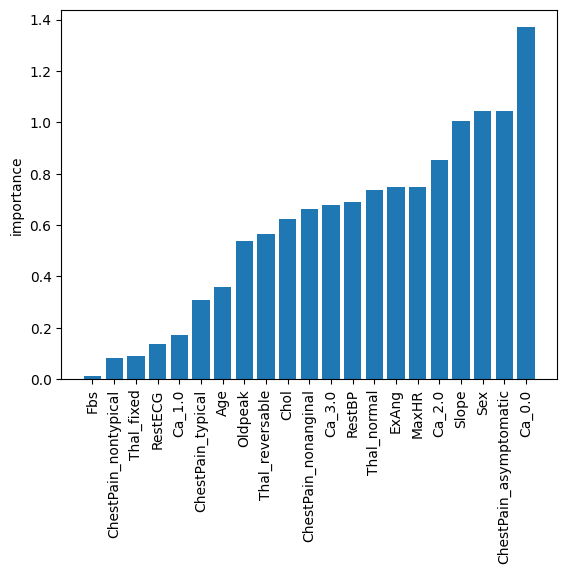

In [7]:
# we only care about the magnitude of the parameters 
weights_importances = np.abs(clf.coef_[0])
columns = csv_dataset.columns 

# sort the columns by importance 
idx = np.argsort(weights_importances)
plt.bar(columns.to_numpy()[idx], weights_importances[idx])
plt.xticks(columns.to_numpy()[idx], rotation = "vertical")
plt.ylabel("importance")

### Importance by shrinkage

As seen during lecture, LASSO gives us a handy way to force the model to focus the attention on only few features, by adding a penalty on the weights.

In [8]:
from sklearn import linear_model
# let's define the set of values we want to test of lambda (the higher, the stronger the regularization)
lambdas = np.linspace(0.001,0.13,30)
weights = []
for l in lambdas:
  # train the model with the specified regularization
  clf = linear_model.Lasso(alpha=l).fit(X_train, y_train)
  # store its parameters
  weights.append(clf.coef_)

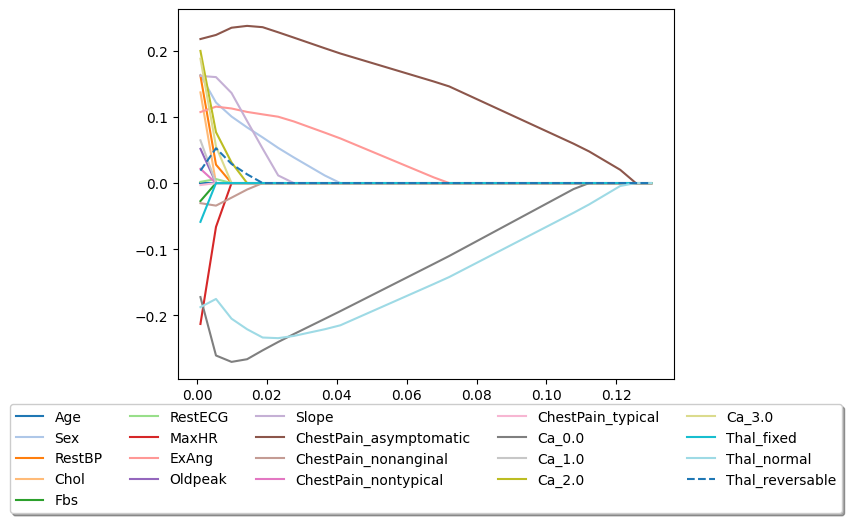

In [9]:
# # plot the parameters of the models varying lambda
weights_arr = np.array(weights)
n_lines = weights_arr.shape[1]
base_colors = plt.cm.tab20(np.linspace(0, 1, min(20, n_lines)))
n_base = len(base_colors)

for i in range(n_lines):
    color = base_colors[i % n_base]
    linestyle = '-' if i < n_base else '--'
    plt.plot(lambdas, weights_arr[:, i], color=color, linestyle=linestyle)

plt.legend(csv_dataset.columns,
           loc='upper center',
           bbox_to_anchor=(0.5, -0.05),
           fancybox=True,
           shadow=True,
           ncol=5)

plt.show()

We can see that `ChestPain_asymptomatic`, `Ca_0.0` and `Thal_normal` are the last that are shrinked to 0 as the lasso penalty increases. Moreover, we can see how the order of importances changes while varying the penalty.

In [10]:
# train a model
from sklearn.ensemble import RandomForestClassifier
clf = RandomForestClassifier(max_depth=5, random_state=0).fit(X_train, y_train)

## ICE curves and Partial Dependence plots

Nonlinear models, such as decision trees and especially random forests, are harder to interpret than linear models. In a linear model, the effect of a feature is usually constant across the whole feature space: increasing a feature always changes the prediction in the same direction and with the same coefficient. 

In contrast, nonlinear mmodels can behave differently in different regions of the feature space. The same feature may increase the prediction for some samples and decrease it for others. Moreover, predictions may depend also on nonlinear interactions between features. 

Visualizing the relationship between the target and more than 2 features becomes difficult. With one feature, we can draw a 2D plot, with 2 we can still visualize the prediction surface in 3D. However, for more than 2 input features, there is no easy visualization. 

To address this problem we can study **how the prediction changes as we vary one (or two) features, while keeping the other fixed**.

Note: the feature vary between the min an the max value from the dataset.

## ICE Curves (local interpretability)
To see how the prediction of _one specific_ sample changes when varying one feature. 

Text(0.5, 1.0, 'ICE curve for the feature Age')

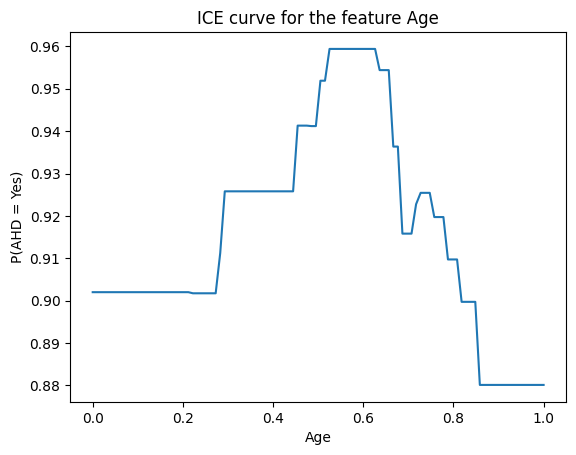

In [11]:
def single_ice_curve(model, sample, feature_idx): 
    range_feature = np.linspace(0, 1, 100) #we want to test 100 values of the feature between 0 and 1 (we normalized the dataset, so all features are between 0 and 1)
    predictions = []
    for value in range_feature:
        sample[0, feature_idx] = value # change the value of the feature to the one we want to test
        pred = model.predict_proba(sample)[0, 1] # get the probability of class 1 (AHD = Yes) for the modified sample
        predictions.append(pred)
    return range_feature, predictions


# plot ICE curve for the feature "Age" for the first sample in the test set
feature_idx = np.where(columns == "Age")[0][0] # get the index of the feature "Age"
range_feature, predictions = single_ice_curve(clf, X_train[0:1].copy(), feature_idx)
plt.plot(range_feature, predictions)
plt.xlabel("Age")
plt.ylabel("P(AHD = Yes)")
plt.title("ICE curve for the feature Age")


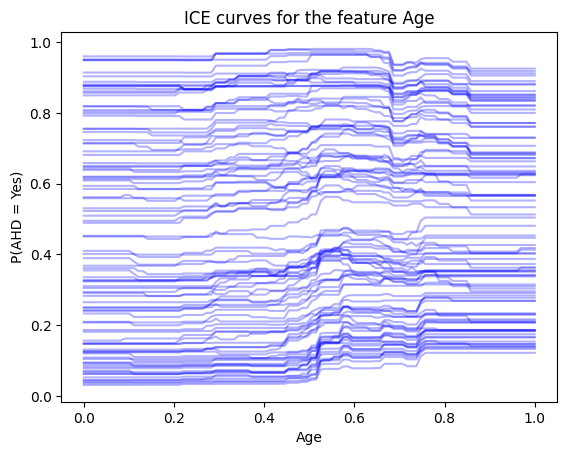

In [12]:
# plot the ice curves for feature "Age" for all the samples 
ice_curves = []
for i in range(X_test.shape[0]):
    feature_idx = np.where(columns == "Age")[0][0] # get the index of the feature "Age"
    range_feature, predictions = single_ice_curve(clf, X_test[i:i+1].copy(), feature_idx)
    ice_curves.append(predictions)
    plt.plot(range_feature, predictions, color="blue", alpha=0.3)
plt.xlabel("Age")
plt.ylabel("P(AHD = Yes)")
plt.title("ICE curves for the feature Age")
plt.show()

## PDPs (global interpretability)
To see how the average prediction changes when varying one feature for all the datapoints in the datset, while marginalizing over the distribution of the other features. 

An important issue is that prediction depends on all input features simultaneously. Therefore, when changing one feature, there is no unique or natural value to assign to the remaining others. 
- Choosing arbitrary fixed values may generate unrealistic combination of features that were never observed in the data, and we have no guarantee on what the model will predict.
- Using the mean of the feature values in the dataset is not a good idea either. 

![pdp.png](figures/pdp.png)

In practice: 
1. we sample points from the dataset. 
2. For each of them, we vary the feature of interest while keeping all the other features fixed to their value for that point. 
3. We compute the corresponding preictions. 
4. We average these predictions across all sampled observations.  
**Hence, a PDP can be interpreted as the average of ICE curves**.

Text(0.5, 1.0, 'PDP curve for the feature Age')

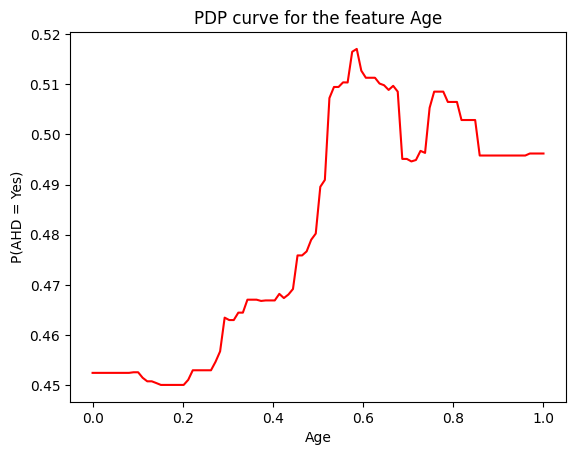

In [13]:
# PDP is average of the ICE curves
pdp = np.mean(ice_curves, axis=0)
plt.plot(range_feature, pdp, color="red")
plt.xlabel("Age")
plt.ylabel("P(AHD = Yes)")
plt.title("PDP curve for the feature Age")

We can see wether the relation between the prediction and the feature is linear, monotonic or more complex. 

## ICE curve for two features. 
The plot might also be done for a pair of variables, and using the third dimension the prediction. 

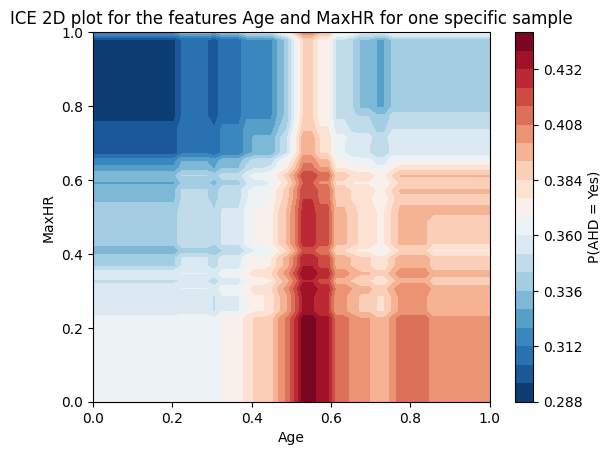

In [14]:
# AGE and MaxHR
age_values = np.linspace(0,1, 50)
maxhr_values = np.linspace(0,1, 50)

# create a grid of values for the two features
age_grid, maxhr_grid = np.meshgrid(age_values, maxhr_values)
predictions_grid = np.zeros_like(age_grid)

for i in range(age_grid.shape[0]):
    for j in range(age_grid.shape[1]):
        sample = X_test[0:1].copy() # take a sample from the test set
        sample[0, np.where(columns == "Age")[0][0]] = age_grid[i, j] # set the value of Age to the one in the grid
        sample[0, np.where(columns == "MaxHR")[0][0]] = maxhr_grid[i, j] # set the value of MaxHR to the one in the grid
        pred = clf.predict_proba(sample)[0, 1] # get the probability of class 1 (AHD = Yes) for the modified sample
        predictions_grid[i, j] = pred
plt.contourf(age_grid, maxhr_grid, predictions_grid, levels=20, cmap="RdBu_r")
plt.xlabel("Age")
plt.ylabel("MaxHR")
plt.title("ICE 2D plot for the features Age and MaxHR for one specific sample")
plt.colorbar(label="P(AHD = Yes)")


# SHAP (Optional)
https://shap.readthedocs.io/en/latest/index.html

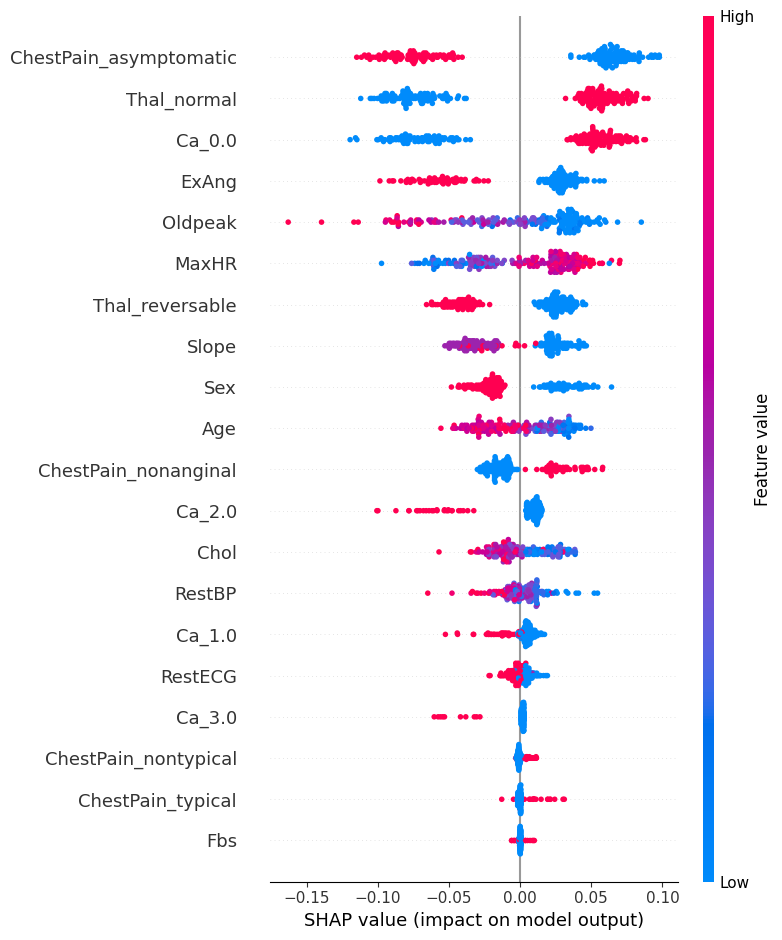

In [15]:
import shap
explainer = shap.Explainer(clf, X_train)  # we use the training set as background dataset for the estimation of the expected value of the model output
shap_values = explainer(X_train)          # shap values of training set (global explanation)
shap_values1 = shap_values[:, :, 0]       # we only care about the shap values for the class 0 (the other class will be just the opposite)

shap.summary_plot(shap_values1, feature_names=csv_dataset.columns)

# Note: shap.Explainer is high-level API that automatically selects the appropriate implementation based on the model type.
# Indeed, there is KernelSHAP which is model-agnostic implementation but it is computationally expensive, and there are 
# other implementations for specific models that are more effficient (e.g., TreeSHAP for tree-based models). You can check the documentation.